<a href="https://colab.research.google.com/github/BP0324144/dspp2966/blob/main/Fitbit_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **Load Data**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving dailyActivity_merged.csv to dailyActivity_merged.csv
Saving dailyIntensities_merged.csv to dailyIntensities_merged.csv
Saving sleepDay_merged.csv to sleepDay_merged.csv


In [5]:
activity = pd.read_csv("dailyActivity_merged.csv")
sleep = pd.read_csv("sleepDay_merged.csv")
intensity = pd.read_csv("dailyIntensities_merged.csv")

In [6]:
activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [7]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Id                  413 non-null    int64 
 1   SleepDay            413 non-null    object
 2   TotalSleepRecords   413 non-null    int64 
 3   TotalMinutesAsleep  413 non-null    int64 
 4   TotalTimeInBed      413 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 16.3+ KB


In [8]:
intensity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDay               940 non-null    object 
 2   SedentaryMinutes          940 non-null    int64  
 3   LightlyActiveMinutes      940 non-null    int64  
 4   FairlyActiveMinutes       940 non-null    int64  
 5   VeryActiveMinutes         940 non-null    int64  
 6   SedentaryActiveDistance   940 non-null    float64
 7   LightActiveDistance       940 non-null    float64
 8   ModeratelyActiveDistance  940 non-null    float64
 9   VeryActiveDistance        940 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 73.6+ KB


## **Data cleaning**

In [9]:
# Standardise column names
activity.columns = activity.columns.str.lower()
sleep.columns = sleep.columns.str.lower()
intensity.columns = intensity.columns.str.lower()

In [10]:
# Convert dates
activity['activitydate'] = pd.to_datetime(activity['activitydate'])
sleep['sleepday'] = pd.to_datetime(sleep['sleepday'])
intensity['activityday'] = pd.to_datetime(intensity['activityday'])

/tmp/ipykernel_1751/3546273486.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep['sleepday'] = pd.to_datetime(sleep['sleepday'])


In [11]:
# Remove duplicates
activity = activity.drop_duplicates()
sleep = sleep.drop_duplicates()
intensity = intensity.drop_duplicates()

## **Agg and merge into one daily dataset**

In [12]:
# get relevant activity columns and rename for consistancy
activity_clean = activity[[
    'id', 'activitydate', 'totalsteps', 'calories',
    'sedentaryminutes', 'veryactiveminutes',
    'fairlyactiveminutes', 'lightlyactiveminutes'
]].rename(columns={'activitydate': 'date'})

# get relevant sleep columns and rename
sleep_clean = sleep[[
    'id', 'sleepday', 'totalminutesasleep', 'totaltimeinbed'
]].rename(columns={'sleepday': 'date'})

# get relevant intensity columns and rename
intensity_clean = intensity[[
    'id', 'activityday',
    'sedentaryminutes', 'lightlyactiveminutes',
    'fairlyactiveminutes', 'veryactiveminutes'
]].rename(columns={'activityday': 'date'})

# merge activity + intensity (they share many columns, so prefer intensity for minutes)
df = pd.merge(
    activity_clean.drop(columns=['sedentaryminutes', 'veryactiveminutes',
                                 'fairlyactiveminutes', 'lightlyactiveminutes']),
    intensity_clean,
    on=['id', 'date'],
    how='left'
)

# then merge sleep
df = pd.merge(df, sleep_clean, on=['id', 'date'], how='left')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    940 non-null    int64         
 1   date                  940 non-null    datetime64[ns]
 2   totalsteps            940 non-null    int64         
 3   calories              940 non-null    int64         
 4   sedentaryminutes      940 non-null    int64         
 5   lightlyactiveminutes  940 non-null    int64         
 6   fairlyactiveminutes   940 non-null    int64         
 7   veryactiveminutes     940 non-null    int64         
 8   totalminutesasleep    410 non-null    float64       
 9   totaltimeinbed        410 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(7)
memory usage: 73.6 KB


### **Merged dataset overview**

After merging the activity, sleep, and intensity data, we can see that the combined dataframe `df` has 940 entries. However, the `totalminutesasleep` and `totaltimeinbed` columns still contain a significant number of null values (only 410 non-null entries out of 940). This confirms the need to handle these missing sleep data points before proceeding with modeling.

In [14]:
df.nunique()

,0
id,33
date,31
totalsteps,842
calories,734
sedentaryminutes,549
lightlyactiveminutes,335
fairlyactiveminutes,81
veryactiveminutes,122
totalminutesasleep,256
totaltimeinbed,242


## **Create some features**

In [15]:
# Sleep efficiency: how much of time in bed is actually sleep
df['sleep_efficiency'] = df['totalminutesasleep'] / df['totaltimeinbed']

In [16]:
df.head()

,id,date,totalsteps,calories,sedentaryminutes,lightlyactiveminutes,fairlyactiveminutes,veryactiveminutes,totalminutesasleep,totaltimeinbed,sleep_efficiency
0,1503960366,2016-04-12,13162,1985,728,328,13,25,327.0,346.0,0.945087
1,1503960366,2016-04-13,10735,1797,776,217,19,21,384.0,407.0,0.943489
2,1503960366,2016-04-14,10460,1776,1218,181,11,30,NaN,NaN,NaN
3,1503960366,2016-04-15,9762,1745,726,209,34,29,412.0,442.0,0.932127
4,1503960366,2016-04-16,12669,1863,773,221,10,36,340.0,367.0,0.926431


In [17]:
df = df.dropna(subset=['totalminutesasleep', 'totaltimeinbed'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410 entries, 0 to 902
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    410 non-null    int64         
 1   date                  410 non-null    datetime64[ns]
 2   totalsteps            410 non-null    int64         
 3   calories              410 non-null    int64         
 4   sedentaryminutes      410 non-null    int64         
 5   lightlyactiveminutes  410 non-null    int64         
 6   fairlyactiveminutes   410 non-null    int64         
 7   veryactiveminutes     410 non-null    int64         
 8   totalminutesasleep    410 non-null    float64       
 9   totaltimeinbed        410 non-null    float64       
 10  sleep_efficiency      410 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(7)
memory usage: 38.4 KB


## **Create lag features**

**Let's predict next day activity based on previous day sleep and intensity.**

In [19]:
# Sort by user and date
df = df.sort_values(['id', 'date'])

# Columns we want to lag
lag_cols = [
    'totalminutesasleep',
    'sleep_efficiency',
    'veryactiveminutes',
    'fairlyactiveminutes',
    'lightlyactiveminutes',
    'sedentaryminutes'
]

# Create lag features
for col in lag_cols:
    df[f'prev_{col}'] = df.groupby('id')[col].shift(1)

In [20]:
df.head()

,id,date,totalsteps,calories,sedentaryminutes,lightlyactiveminutes,fairlyactiveminutes,veryactiveminutes,totalminutesasleep,totaltimeinbed,sleep_efficiency,prev_totalminutesasleep,prev_sleep_efficiency,prev_veryactiveminutes,prev_fairlyactiveminutes,prev_lightlyactiveminutes,prev_sedentaryminutes
0,1503960366,2016-04-12,13162,1985,728,328,13,25,327.0,346.0,0.945087,NaN,NaN,NaN,NaN,NaN,NaN
1,1503960366,2016-04-13,10735,1797,776,217,19,21,384.0,407.0,0.943489,327.0,0.945087,25.0,13.0,328.0,728.0
3,1503960366,2016-04-15,9762,1745,726,209,34,29,412.0,442.0,0.932127,384.0,0.943489,21.0,19.0,217.0,776.0
4,1503960366,2016-04-16,12669,1863,773,221,10,36,340.0,367.0,0.926431,412.0,0.932127,29.0,34.0,209.0,726.0
5,1503960366,2016-04-17,9705,1728,539,164,20,38,700.0,712.0,0.983146,340.0,0.926431,36.0,10.0,221.0,773.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 410 entries, 0 to 902
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         410 non-null    int64         
 1   date                       410 non-null    datetime64[ns]
 2   totalsteps                 410 non-null    int64         
 3   calories                   410 non-null    int64         
 4   sedentaryminutes           410 non-null    int64         
 5   lightlyactiveminutes       410 non-null    int64         
 6   fairlyactiveminutes        410 non-null    int64         
 7   veryactiveminutes          410 non-null    int64         
 8   totalminutesasleep         410 non-null    float64       
 9   totaltimeinbed             410 non-null    float64       
 10  sleep_efficiency           410 non-null    float64       
 11  prev_totalminutesasleep    386 non-null    float64       
 12  prev_sleep_ef

## **Create target variable (next day activity level)**

In [22]:
# Define active minutes today
df['active_minutes'] = df['veryactiveminutes'] + df['fairlyactiveminutes']

# Next-day active minutes
df['next_day_active_minutes'] = df.groupby('id')['active_minutes'].shift(-1)

# Drop rows without next-day info or lag features
df_model = df.dropna(subset=['next_day_active_minutes'] + [f'prev_{c}' for c in lag_cols]).copy()

# 3-class activity level (low / medium / high)
quantiles = df_model['next_day_active_minutes'].quantile([0.33, 0.66])
q1, q2 = quantiles[0.33], quantiles[0.66]

def label_activity(x):
    if x <= q1:
        return 'low'
    elif x <= q2:
        return 'medium'
    else:
        return 'high'

df_model['next_day_activity_level'] = df_model['next_day_active_minutes'].apply(label_activity)

In [23]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 363 entries, 1 to 901
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         363 non-null    int64         
 1   date                       363 non-null    datetime64[ns]
 2   totalsteps                 363 non-null    int64         
 3   calories                   363 non-null    int64         
 4   sedentaryminutes           363 non-null    int64         
 5   lightlyactiveminutes       363 non-null    int64         
 6   fairlyactiveminutes        363 non-null    int64         
 7   veryactiveminutes          363 non-null    int64         
 8   totalminutesasleep         363 non-null    float64       
 9   totaltimeinbed             363 non-null    float64       
 10  sleep_efficiency           363 non-null    float64       
 11  prev_totalminutesasleep    363 non-null    float64       
 12  prev_sleep_ef

## **Add engineered features**

In [24]:
# Sleep deficit (assuming 8 hours = 480 minutes)
df_model['prev_sleep_deficit'] = 480 - df_model['prev_totalminutesasleep']

# Sedentary ratio (out of 1440 minutes per day)
df_model['prev_sedentary_ratio'] = df_model['prev_sedentaryminutes'] / 1440

# Intensity ratio (vigorous vs light)
df_model['prev_intensity_ratio'] = (
    df_model['prev_veryactiveminutes'] /
    (df_model['prev_lightlyactiveminutes'] + 1)  # avoid division by zero
)

# Total activity minutes
df_model['prev_total_activity'] = (
    df_model['prev_veryactiveminutes'] +
    df_model['prev_fairlyactiveminutes'] +
    df_model['prev_lightlyactiveminutes']
)

# Activity balance (vigorous vs total)
df_model['prev_activity_balance'] = (
    df_model['prev_veryactiveminutes'] /
    (df_model['prev_total_activity'] + 1)
)

# Sleep efficiency band (categorical)
df_model['prev_sleep_eff_band'] = pd.cut(
    df_model['prev_sleep_efficiency'],
    bins=[0, 0.8, 0.9, 1.0],
    labels=[0, 1, 2]
).astype(float)

### **Engineered features**

To enrich the dataset and provide more predictive signals for the models, several new features were engineered based on the previous day's data:

*   **`prev_sleep_deficit`**: Calculates how much sleep was missed compared to an ideal 8 hours (480 minutes). This could capture the impact of insufficient sleep.
*   **`prev_sedentary_ratio`**: Represents the proportion of the previous day spent in sedentary activities (out of 1440 minutes in a day). A high ratio might indicate lower overall activity potential.
*   **`prev_intensity_ratio`**: Measures the ratio of very active minutes to lightly active minutes. This could reflect the intensity of previous day's workout effort.
*   **`prev_total_activity`**: Sums up all active minutes (very, fairly, lightly) to give an overall measure of previous day's activity level.
*   **`prev_activity_balance`**: Indicates the proportion of very active minutes within the total activity. This aims to capture whether the activity was primarily vigorous or more balanced.
*   **`prev_sleep_eff_band`**: Categorizes the `prev_sleep_efficiency` into bands (low, medium, high). This can help the model identify non-linear relationships with sleep efficiency.

## **Prepare modeling dataset**

In [25]:
# get features
feature_cols = [
    # original lag features
    'prev_totalminutesasleep',
    'prev_sleep_efficiency',
    'prev_veryactiveminutes',
    'prev_fairlyactiveminutes',
    'prev_lightlyactiveminutes',
    'prev_sedentaryminutes',

    # engineered features
    'prev_sleep_deficit',
    'prev_sedentary_ratio',
    'prev_intensity_ratio',
    'prev_total_activity',
    'prev_activity_balance',
    'prev_sleep_eff_band'
]

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_model['activity_label_encoded'] = le.fit_transform(df_model['next_day_activity_level'])

# split data
X = df_model[feature_cols]
y = df_model['activity_label_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **Train baseline model**

In [26]:
# first predictive model using logistic regression
#log_reg = LogisticRegression(max_iter=1000)
#log_reg.fit(X_train, y_train)

#y_pred = log_reg.predict(X_test)
#y_proba = log_reg.predict_proba(X_test)[:, 1]

#print(classification_report(y_test, y_pred))
#print("ROC AUC:", roc_auc_score(y_test, y_proba))

## **Random forest model (for comparison)**

In [27]:
# random forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
#y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
#print("ROC AUC (RF):", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       0.61      0.71      0.65        24
           1       0.47      0.32      0.38        25
           2       0.32      0.38      0.35        24

    accuracy                           0.47        73
   macro avg       0.47      0.47      0.46        73
weighted avg       0.47      0.47      0.46        73



### **Random forest model results**

The Random Forest Classifier achieved an overall accuracy of **47%** on the test set. Here's a breakdown of its performance across the three activity levels:

*   **High Activity (label 0)**: The model performs best for this class, with a precision of 0.61 (61% of predictions for 'high' were correct) and a recall of 0.71 (71% of actual 'high' days were correctly identified). The F1-score is 0.65.
*   **Medium Activity (label 1)**: Performance is moderate, with a precision of 0.47 and recall of 0.32. The F1-score is 0.38, indicating difficulty in accurately predicting 'medium' activity.
*   **Low Activity (label 2)**: This class is the most challenging for the model, showing a low precision of 0.32 and recall of 0.38. The F1-score is 0.35, suggesting the model struggles to identify 'low' activity days reliably.

These results indicate that while the model has some predictive power, especially for 'high' activity, there's significant room for improvement, particularly for the 'medium' and 'low' activity levels.

## **Train XGBoost**

In [28]:
# xgboost
xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    objective='multi:softprob',
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
#y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
#print("ROC AUC (XGB):", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.57      0.67      0.62        24
           1       0.52      0.52      0.52        25
           2       0.30      0.25      0.27        24

    accuracy                           0.48        73
   macro avg       0.46      0.48      0.47        73
weighted avg       0.46      0.48      0.47        73



### **XGBoost model results**

The XGBoost Classifier achieved a slightly higher overall accuracy of **48%** on the test set, similar to the Random Forest model. Let's look at its performance for each class:

*   **High Activity (label 0)**: Similar to Random Forest, XGBoost performs relatively well, with a precision of 0.57 and recall of 0.67. The F1-score is 0.62.
*   **Medium Activity (label 1)**: XGBoost shows slightly better performance for 'medium' activity compared to Random Forest, with both precision and recall at 0.52 and an F1-score of 0.52.
*   **Low Activity (label 2)**: This remains the most challenging class, with a low precision of 0.30 and an even lower recall of 0.25 (meaning only 25% of actual 'low' activity days were caught by the model). The F1-score is 0.27.

Both models exhibit similar overall performance, struggling most with the 'low' activity class. The XGBoost model shows a slight edge in balanced performance for 'medium' activity but a worse recall for 'low' activity compared to Random Forest.

## **Create readiness score**

In [29]:
# Find which encoded label corresponds to "high"
high_index = list(le.classes_).index('high')

df_model['readiness_score'] = rf.predict_proba(X)[:, high_index]

def readiness_label(score):
    if score >= 0.7:
        return 'High'
    elif score >= 0.4:
        return 'Medium'
    else:
        return 'Low'

df_model['readiness_category'] = df_model['readiness_score'].apply(readiness_label)

### **Readiness score and category**

A **`readiness_score`** has been created to provide a more granular and interpretable measure of a user's potential for high activity on the next day. This score is derived from the Random Forest model's predicted probability of the 'high' activity class.

*   **How it's calculated**: `rf.predict_proba(X)[:, high_index]` gives the probability that the next day's activity will be 'high' for each data point.
*   **`readiness_category`**: To make the score actionable, it's categorized into three levels:
    *   **'High'**: If `readiness_score` is 0.7 or greater.
    *   **'Medium'**: If `readiness_score` is between 0.4 and 0.7.
    *   **'Low'**: If `readiness_score` is less than 0.4.

This provides a quick and intuitive way to understand the model's confidence in a user's potential for high activity on the upcoming day.

In [30]:
df_model.head()

,id,date,totalsteps,calories,sedentaryminutes,lightlyactiveminutes,fairlyactiveminutes,veryactiveminutes,totalminutesasleep,totaltimeinbed,...,next_day_activity_level,prev_sleep_deficit,prev_sedentary_ratio,prev_intensity_ratio,prev_total_activity,prev_activity_balance,prev_sleep_eff_band,activity_label_encoded,readiness_score,readiness_category
1,1503960366,2016-04-13,10735,1797,776,217,19,21,384.0,407.0,...,high,153.0,0.505556,0.075988,366.0,0.068120,2.0,0,0.723333,High
3,1503960366,2016-04-15,9762,1745,726,209,34,29,412.0,442.0,...,medium,96.0,0.538889,0.096330,257.0,0.081395,2.0,2,0.640000,Medium
4,1503960366,2016-04-16,12669,1863,773,221,10,36,340.0,367.0,...,high,68.0,0.504167,0.138095,272.0,0.106227,2.0,0,0.503333,Medium
5,1503960366,2016-04-17,9705,1728,539,164,20,38,700.0,712.0,...,high,140.0,0.536806,0.162162,267.0,0.134328,2.0,0,0.563333,Medium
7,1503960366,2016-04-19,15506,2035,775,264,31,50,304.0,320.0,...,medium,-220.0,0.374306,0.230303,222.0,0.170404,2.0,2,0.223333,Low


## **Visualization**

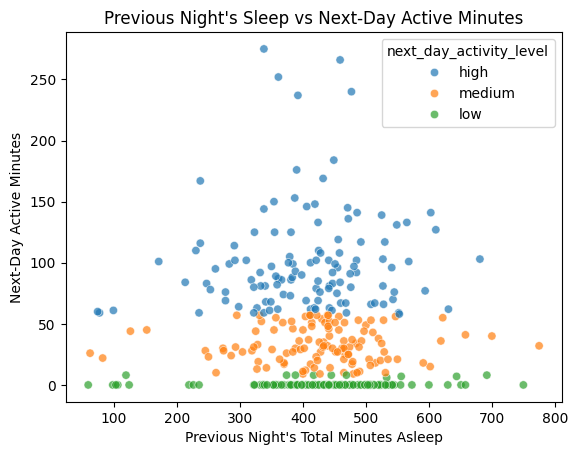

In [31]:
# sleep vs next day steps
sns.scatterplot(
    data=df_model,
    x='prev_totalminutesasleep',
    y='next_day_active_minutes',
    hue='next_day_activity_level',
    alpha=0.7
)
plt.title("Previous Night's Sleep vs Next-Day Active Minutes")
plt.xlabel("Previous Night's Total Minutes Asleep")
plt.ylabel("Next-Day Active Minutes")
plt.show()

### **Visualization: Previous night's sleep vs next-day active minutes**

This scatter plot visualizes the relationship between the previous night's total minutes asleep and the next day's active minutes, colored by the predicted next-day activity level.

**Insights:**
*   There isn't a clear linear relationship; simply more sleep doesn't automatically mean more next-day active minutes.
*   The clusters for 'low', 'medium', and 'high' activity levels show some overlap, which aligns with the moderate accuracy of the classification models.
*   It suggests that while sleep duration is a factor, it interacts with other variables to determine the next day's activity, or perhaps the relationship is not simple and linear.

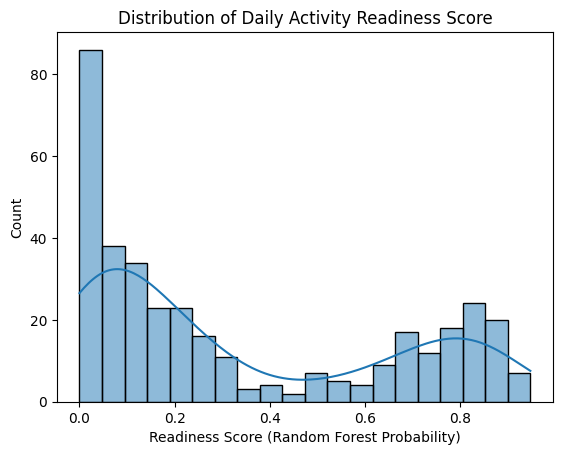

In [32]:
# are random forest model outputs balanced or skewed
sns.histplot(df_model['readiness_score'], bins=20, kde=True)
plt.title("Distribution of Daily Activity Readiness Score")
plt.xlabel("Readiness Score (Random Forest Probability)")
plt.show()

In [33]:
**This shows the data is skewed but in a bimodal way, the features are giving the model enough signal to split the data into two clusters.**

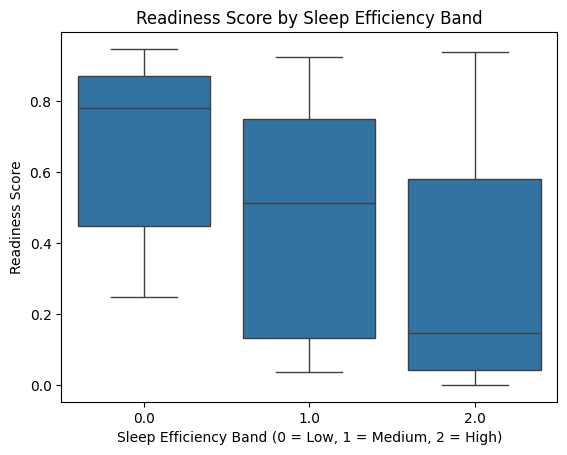

In [34]:
# rediness score vs sleep efficiency band (does better sleep efficiency = higher readiness?)
sns.boxplot(
    data=df_model,
    x='prev_sleep_eff_band',
    y='readiness_score'
)
plt.title("Readiness Score by Sleep Efficiency Band")
plt.xlabel("Sleep Efficiency Band (0 = Low, 1 = Medium, 2 = High)")
plt.ylabel("Readiness Score")
plt.show()

### **Visualization: Readiness score by sleep efficiency band**

This box plot examines how the calculated `readiness_score` varies across different `prev_sleep_eff_band` categories (0 = Low, 1 = Medium, 2 = High).

**Insights:**
*   As expected, there's a clear trend: higher sleep efficiency bands tend to correspond with higher median readiness scores.
*   Users in `prev_sleep_eff_band` 2 (high efficiency) generally have significantly higher readiness scores, indicating the model correctly associates better sleep quality with a higher probability of next-day high activity.
*   This plot validates that sleep efficiency is a strong indicator captured by the readiness score.

<Axes: xlabel='next_day_activity_level', ylabel='prev_sleep_efficiency'>

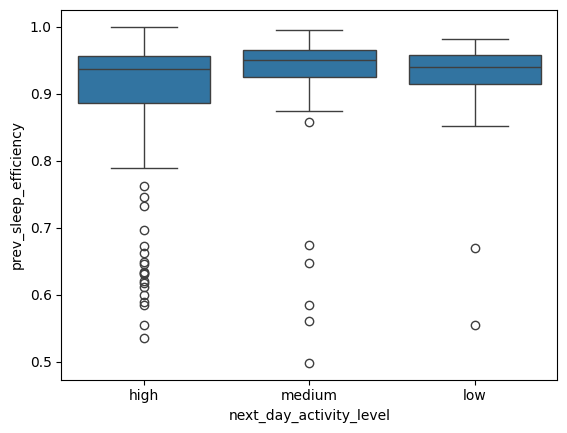

In [35]:
sns.boxplot(
    data=df_model,
    x='next_day_activity_level',
    y='prev_sleep_efficiency'
)

### **Visualization: Previous sleep efficiency vs next-day activity level**

This box plot illustrates the distribution of `prev_sleep_efficiency` for each `next_day_activity_level` (low, medium, high).

**Insights:**
*   There's a subtle but noticeable trend: as `next_day_activity_level` increases, the median `prev_sleep_efficiency` also tends to slightly increase.
*   This reinforces that better previous night's sleep efficiency is generally associated with higher activity levels on the following day, supporting its importance as a predictive feature.
*   The overlap in distributions indicates that sleep efficiency alone is not a perfect predictor, and other factors contribute to the next day's activity.

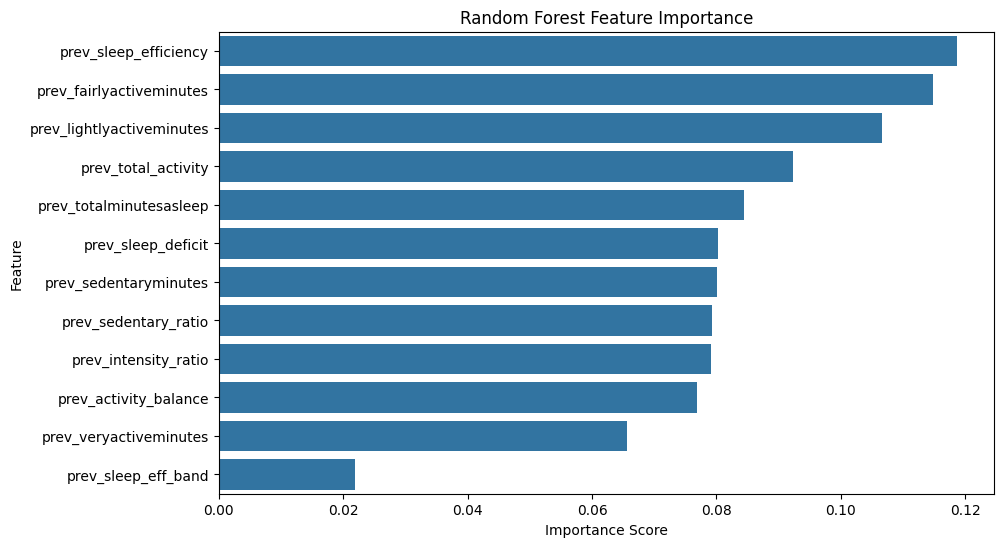

In [36]:
# feature importance plot
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
sns.barplot(
    x=importances[indices],
    y=np.array(feature_cols)[indices]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### **Visualization: Random forest feature importance**

This bar plot displays the importance of each feature in predicting `next_day_activity_level` as determined by the Random Forest model.

**Insights:**
*   **`prev_sleep_efficiency`** and **`prev_fairlyactiveminutes`** are identified as the most important features. This highlights that both the quality of previous night's sleep and moderate physical activity from the day before are key drivers in predicting subsequent activity.
*   Other significant features include `prev_totalminutesasleep`, `prev_veryactiveminutes`, and `prev_total_activity`.
*   Features like `prev_sleep_eff_band` (the categorical version of sleep efficiency) have lower importance than the continuous `prev_sleep_efficiency`, suggesting the continuous form provides more information to the model.
*   Understanding feature importance helps in identifying which aspects of a user's daily data are most influential in predicting their activity patterns.